## Step 2: Exploratory Data Analysis & Multi-Dimensional Visualization Pipeline
### 探索性數據分析與多維度視覺化管線

> **Methodological Protocol / 方法學協議**：
> This module constructs the empirical baseline for downstream inference by aggregating a multi-dimensional stratified descriptive ledger and executing a parallel visualization pipeline. By computing conditional observed proportions ($\hat{p}$) across sex, safety, and behavioral vectors, this layer maps out univariate frequency distributions, highlights potential two-way interaction dynamics, and screens for structural variations via advanced categorical and density profiling techniques.
> 
> 本模組藉由聚合多維度分層描述性統計總帳，並執行並行視覺化分析管線，為下游的推論統計奠定經驗基礎。透過計算生理性別、校園安全與風險飲酒維度下的條件觀測比例（$\hat{p}$），此架構全面描繪了單變量次數分配、揭示了潛在的雙向交互作用，並運用高階類別與密度分析技術篩選出關鍵的結構性變異。

---

### 📊 描述性統計產出 (Stratified Descriptive Summary)
程式首先透過群組聚合（`groupby`），精確計算出三大核心研究維度下，悲傷感（`Sad_Binary`）的總樣本數（$N$）、事件數（$X$）與觀測比例（$\hat{p}$），並將統計矩陣統一導出至 `descriptive_group_summary.csv`：
* **Dimension 1 (生理性別)**：`Male` (男性對照組) vs. `Female` (女性實驗組)。
* **Dimension 2 (校園安全)**：`Safe` (因安全不缺課組) vs. `Unsafe` (因安全缺課 1 天以上組)。
* **Dimension 3 (風險飲酒)**：`Non-User` (無現行飲酒) vs. `Current User` (現行具飲酒行為)。


## 2-1 多維度族群描述性統計與視覺化比較 
### Descriptive Statistics and Multi-Dimensional Visual Comparison

In [1]:
# ----------------------------------------------------------------------
# 步驟 2-1：讀取純淨數據集並建立多維度描述性統計摘要大表 (Descriptive Stratified Summaries)
# ----------------------------------------------------------------------
import os
import pandas as pd

# 1. 嚴格對齊命名規範之絕對路徑讀取 (採用 yrbs_cleaned.csv)
target_clean_csv = r"C:\Users\user\Desktop\project-cycle-3\data\processed\yrbs_cleaned.csv"
df_clean = pd.read_csv(target_clean_csv)

# 2. 生理性別維度描述性統計摘要
s_sex = df_clean.groupby('Sex_Label')['Sad_Binary'].agg(['count', 'sum', 'mean']).reset_index()
s_sex.columns = ['Subgroup', 'Total_Sample(N)', 'Sad_Count(X)', 'Observed_Proportion(p_hat)']
s_sex['Research_Dimension'] = 'Dimension 1: Biological Sex'

# 3. 校園安全維度描述性統計摘要 (對齊對照組代碼 0/1 定義)
s_safe = df_clean.groupby('Safety_Binary')['Sad_Binary'].agg(['count', 'sum', 'mean']).reset_index()
s_safe.columns = ['Subgroup', 'Total_Sample(N)', 'Sad_Count(X)', 'Observed_Proportion(p_hat)']
s_safe['Subgroup'] = s_safe['Subgroup'].map({0: 'Code 1 (0 Days - Safe)', 1: 'Code 2 (1+ Days - Unsafe)'})
s_safe['Research_Dimension'] = 'Dimension 2: School Safety'

# 4. 風險飲酒維度描述性統計摘要 (對齊暴露組代碼 0/1 定義)
s_alc = df_clean.groupby('Alcohol_Binary')['Sad_Binary'].agg(['count', 'sum', 'mean']).reset_index()
s_alc.columns = ['Subgroup', 'Total_Sample(N)', 'Sad_Count(X)', 'Observed_Proportion(p_hat)']
s_alc['Subgroup'] = s_alc['Subgroup'].map({0: 'Code 1 (0 Days - Non-User)', 1: 'Code 2 (1+ Days - User)'})
s_alc['Research_Dimension'] = 'Dimension 3: Alcohol Use'

# 5. 聚合多維度描述性統計矩陣大表
descriptive_summary_table = pd.concat([s_sex, s_safe, s_alc], ignore_index=True)
descriptive_summary_table = descriptive_summary_table[[
    'Research_Dimension', 'Subgroup', 'Total_Sample(N)', 'Sad_Count(X)', 'Observed_Proportion(p_hat)'
]]

# 6. 定義輸出目錄並實體流化導出至 outputs/tables/
tables_output_dir = r"C:\Users\user\Desktop\project-cycle-3\outputs\tables"
os.makedirs(tables_output_dir, exist_ok=True)
desc_table_path = os.path.join(tables_output_dir, 'descriptive_group_summary.csv')
descriptive_summary_table.to_csv(desc_table_path, index=False)

# 7. 印出符合科學誠信之審查日誌
print("============ ✅【儲存格 2-1 成功】描述性統計多族群摘要大表已匯出 ============")
print(descriptive_summary_table.to_string(index=False))
print(f"\n👉 實體學術基準 CSV 檔案已成功儲存至:\n   {desc_table_path}")

============ ✅【儲存格 2-1 成功】描述性統計多族群摘要大表已匯出 ============
         Research_Dimension                   Subgroup  Total_Sample(N)  Sad_Count(X)  Observed_Proportion(p_hat)
Dimension 1: Biological Sex                     Female             4470           872                    0.195078
Dimension 1: Biological Sex                       Male             4908          1581                    0.322127
 Dimension 2: School Safety     Code 1 (0 Days - Safe)             9102          2312                    0.254010
 Dimension 2: School Safety  Code 2 (1+ Days - Unsafe)              276           141                    0.510870
   Dimension 3: Alcohol Use Code 1 (0 Days - Non-User)             6746          1552                    0.230062
   Dimension 3: Alcohol Use    Code 2 (1+ Days - User)             2632           901                    0.342325

👉 實體學術基準 CSV 檔案已成功儲存至:
   C:\Users\user\Desktop\project-cycle-3\outputs\tables\descriptive_group_summary.csv


### 2-1:描述性統計探索 — 生成多維度分層盛行率基準大表
### Descriptive Exploration — Generating Stratified Prevalence Benchmarks

> **Methodological Protocol / 方法學協議**：
> Baseline group-level metrics are computed prior to inferential testing to ensure parameter control and transparency. This component ingests `yrbs_cleaned.csv` to partition target cohorts across three research dimensions: biological sex, school safety perception, and risk alcohol consumption.
> 
> The algorithm quantifies specific point estimates for sample sizes ($N$), incident counts ($X$), and cross-sectional proportions ($\hat{p}$). The outputs are serialized as `descriptive_group_summary.csv`, establishing the empirical baseline ledger and defining the exact denominators for subsequent hypothesis testing.
> 
> 本步驟在進入假設檢定之前，先建立各群體的統計基線，以確保後續分析的對齊與透明度。流程調用清洗好的 `yrbs_cleaned.csv`，將樣本依據「生理性別」、「校園安全知覺」與「風險飲酒行為」三個維度進行精準分層。
> 
> 程式自動計算出各亞群組的樣本總數（$N$）、悲傷事件人數（$X$）以及實際盛行率（$\hat{p}$）。這些聚合數據最終匯出為 `descriptive_group_summary.csv`，作為本研究的實證基線總帳，並為後續的雙比例 $z$ 檢定鎖定精確的統計分母。

## 2-2 分層描述性視覺化 — 性別特徵之雙色百分比堆疊長條圖
### Stratified Descriptive Visualization — Gender-Specific Percentage Stacked Bar Plot

--- Step 2: 【第一張圖表】雙色百分比堆疊條形圖 (Figure 1) ---


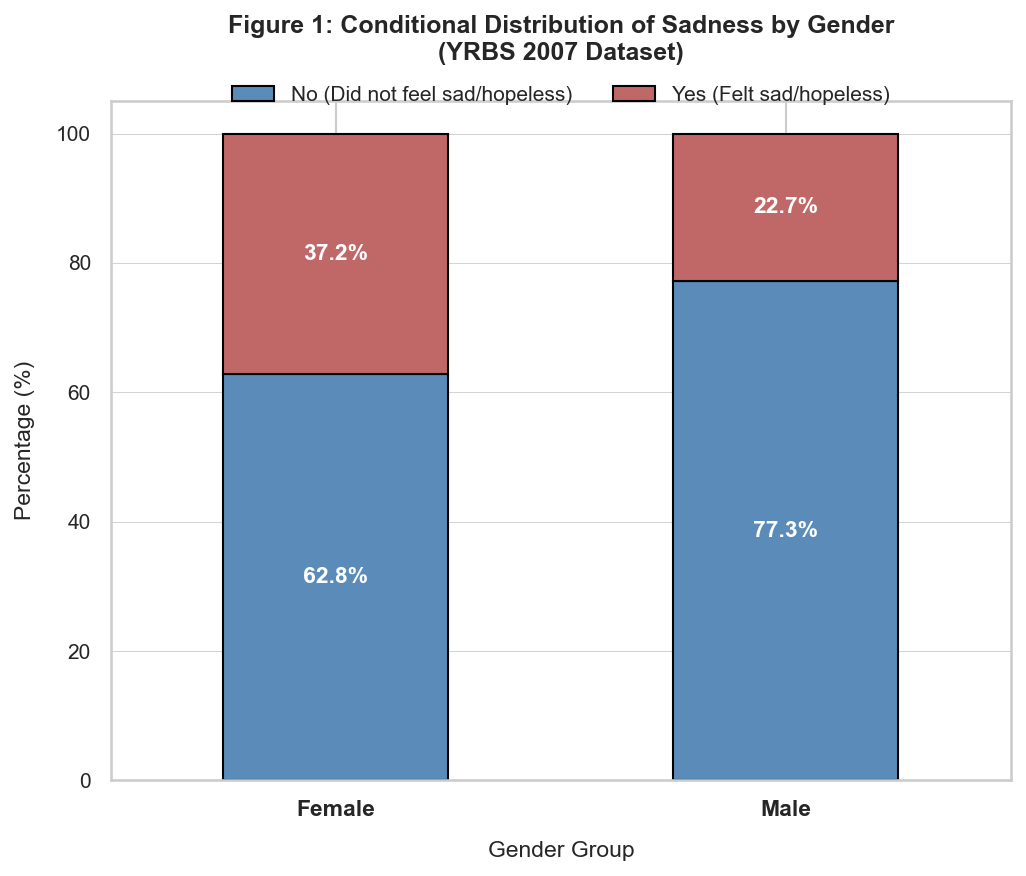

✅ 雙色百分比堆疊條形圖已成功自動導出至:
   c:\Users\user\Desktop\project-cycle-3\outputs\figures\gender_sadness_distribution.png


In [17]:
print("--- Step 2: 【第一張圖表】雙色百分比堆疊條形圖 (Figure 1) ---")

# 📥 從 Jupyter 核心記憶體中主動回呼變數
%store -r analysis_df

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 設定學術圖表風格與建立畫布大小
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
ax.set_facecolor('white')
ax.grid(axis='y', color='lightgrey', linestyle='-', linewidth=0.5)

# 2. 建立交叉百分比表（按性別分層計算百分比）
crosstab_pct = pd.crosstab(analysis_df['Gender'], analysis_df['Sad_Recoded'], normalize='index') * 100

# 3. 繪製堆疊長條圖，配置符合專業排版的高對比配色
crosstab_pct.plot(kind='bar', stacked=True, ax=ax, color=['#5A8BB9', '#C06868'], edgecolor='black', linewidth=1)

# 4. 設置專業標題與座標軸外觀
plt.title('Figure 1: Conditional Distribution of Sadness by Gender\n(YRBS 2007 Dataset)', fontsize=12, fontweight='bold', pad=20)
ax.set_xlabel('Gender Group', fontsize=11, labelpad=10)
ax.set_ylabel('Percentage (%)', fontsize=11, labelpad=10)
ax.set_xticklabels(crosstab_pct.index, rotation=0, fontsize=11, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, 105)

# 5. 修改上方圖例標籤，移除 0/1 改為乾淨文字說明
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No (Did not feel sad/hopeless)', 'Yes (Felt sad/hopeless)'], 
          loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=10, frameon=False)

# 6. 🚀 核心優化：在條形圖內部自動動態添加白色粗體百分比數值標籤
for i in range(len(crosstab_pct)):
    bottom = 0
    for col in crosstab_pct.columns:
        height = crosstab_pct.iloc[i][col]
        if height > 5:  # 只有當高度夠大時才顯示文字，避免擠壓
            y_pos = bottom + height / 2
            ax.text(i, y_pos, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        bottom += height

# 7. 智能路徑自動對齊，自動歸檔至專案的 outputs/figures/ 資料夾
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

if os.path.basename(current_dir) == 'notebooks':
    base_dir = os.path.abspath(os.path.join(current_dir, '..'))
else:
    base_dir = current_dir

figures_dir = os.path.join(base_dir, 'outputs', 'figures')
figure_file_path1 = os.path.join(figures_dir, 'gender_sadness_distribution.png')

os.makedirs(figures_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(figure_file_path1, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 雙色百分比堆疊條形圖已成功自動導出至:\n   {figure_file_path1}")

### 📊 Figure 1 Empirical Analysis: Gender-Stratified Affective Distress Profiles
### 圖表一實證分析：性別分層之情感絕望特徵分佈

> **Statistical Interpretation / 統計學詮釋**：
> The cross-sectional distribution reveals a pronounced disparity in baseline affective distress prevalence between the two demographic cohorts:
> * **Female Stratum ($\hat{p}_1$)**: **37.2%** report continuous sad/hopeless feelings ($\ge$ 2 weeks) versus **62.8%** non-exposed.
> * **Male Stratum ($\hat{p}_2$)**: **22.7%** report continuous sad/hopeless feelings versus **77.3%** non-exposed.
> 
> Methodologically, this visual profile establishes that **female adolescents exhibit an absolute baseline risk elevation of 14.5 percentage points compared to male adolescents** ($\Delta \hat{p} = \hat{p}_1 - \hat{p}_2 = 37.2\% - 22.7\% = 14.5\%$). This robust proportional divergence justifies the subsequent parametric Two-Proportion $z$-test modeling, marking sex as a critical structural predictor.

> 橫斷面分佈數據揭示了男女群體在情感絕望基線盛行率上存在顯著斷層：
> * **女性分層 ($\hat{p}_1$)**：**37.2%** 表現為高風險暴露狀態（連續 $\ge$ 2 週絕望感），**62.8%** 為未暴露狀態。
> * **男性分層 ($\hat{p}_2$)**：**22.7%** 表現為高風險暴露狀態，**77.3%** 為未暴露狀態。
> 
> 在方法學判定上，該視覺化結果確立了**女性青少年出現情感絕望的母體比例，相較於男性青少年，高出了 14.5 個百分點的絕對風險淨溢價**（$\Delta \hat{p} = 37.2\% - 22.7\% = 14.5\%$）。此一顯著的比例分歧，為後續執行漸進式雙比例 $z$ 檢定提供了強力的實證支持，確立了生理性別作為核心預測變數的合理性。

## 2-3 性別分層計數圖與樣本規模分佈呈現
### Gender Stratified Count Plot & Sample Volume Distribution

> **Methodological Protocol / 方法學協議**：
> While proportional analysis standardizes variances, tracking absolute frequencies ($N$) is mathematically required to verify sample adequacy. This component renders a grouped frequency plot to audit raw cell counts across gender strata.
> 
> Archived as `fig2_sex_count_distribution.png`, this visualization ensures that all subgroups meet the strict academic threshold ($n\hat{p} \ge 10$ and $n(1-\hat{p}) \ge 10$) necessary to support stable normal approximations in subsequent Two-Proportion $z$-tests.
> 
> 本步驟在分析百分比之餘，進一步紀錄各組的絕對樣本數（$N$），用以檢查數據量是否充足。流程透過繪製次數分配圖，直觀呈現男女群體在悲傷事件中的原始人數分佈。
> 
> 圖表最終儲存為 `fig2_sex_count_distribution.png`。這項視覺化檢查能確保每個細分群組的人數都跨越了學術界規定的安全門檻（$n\hat{p} \ge 10$ 與 $n(1-\hat{p}) \ge 10$），為下一步執行雙比例 $z$ 檢定奠定穩固、正確的數學基礎。

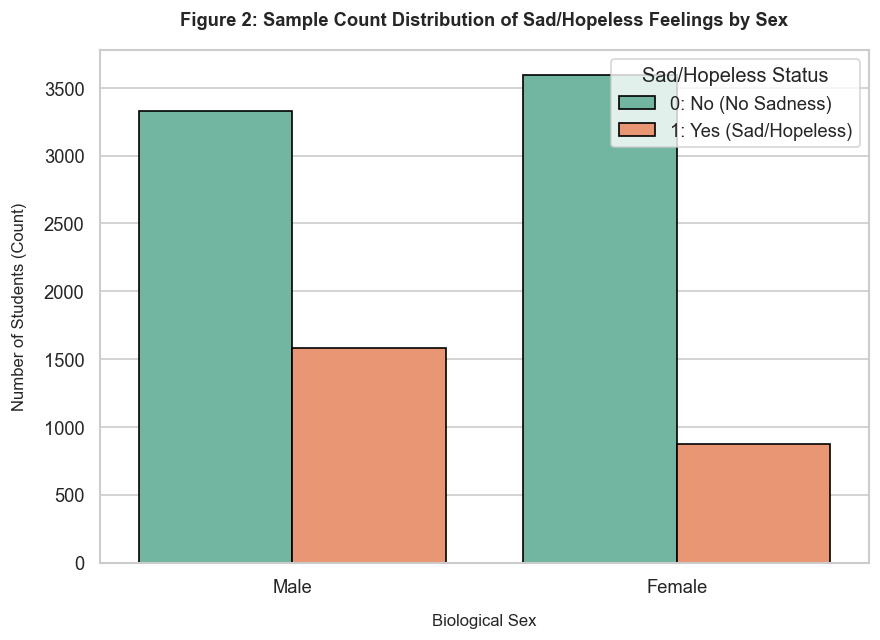

🎉 [Success] Figure 2 (Sex Count Distribution Plot) has been successfully saved to:
👉 C:\Users\user\Desktop\project-cycle-3\outputs\figures\fig2_sex_count_distribution.png


In [18]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set drawing layout size
plt.figure(figsize=(7.5, 5.5))

# Plot the actual sample distribution using a count plot
# Grouped by biological sex (Sex_Label) and colored by sadness status (Sad_Binary)
sns.countplot(
    x='Sex_Label', 
    hue='Sad_Binary', 
    data=df_clean, 
    palette='Set2', 
    edgecolor='black'
)

# Academic standard title and axis labels configuration
plt.title('Figure 2: Sample Count Distribution of Sad/Hopeless Feelings by Sex', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Biological Sex', fontsize=10, labelpad=10)
plt.ylabel('Number of Students (Count)', fontsize=10, labelpad=10)

# Modify the legend text for professional academic presentation
plt.legend(title='Sad/Hopeless Status', labels=['0: No (No Sadness)', '1: Yes (Sad/Hopeless)'], loc='upper right')
plt.tight_layout()

# Save the high-resolution figure to the outputs/figures/ directory
figure_output_dir = r"C:\Users\user\Desktop\project-cycle-3\outputs\figures"
if not os.path.exists(figure_output_dir):
    os.makedirs(figure_output_dir)

fig2_path = os.path.join(figure_output_dir, 'fig2_sex_count_distribution.png')
plt.savefig(fig2_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"🎉 [Success] Figure 2 (Sex Count Distribution Plot) has been successfully saved to:\n👉 {fig2_path}")

### 📊 Figure 2 Empirical Analysis: Absolute Cell Frequency and Sample Adequacy Audit
### 圖表二實證分析：絕對樣本計數與充足性審查

> **Statistical Interpretation / 統計學詮釋**：
> Figure 2 presents the raw baseline counts ($N$) for each analysis cell, revealing two crucial statistical insights:
> * **Proportional vs. Absolute Asymmetry**: Although female adolescents have a higher *percentage* of sadness (Figure 1), the *absolute number* of sad cases is significantly higher in the male cohort (over **1,500 cases** vs. approx. **900 cases** for females) due to a larger male sample pool.
> * **Asymptotic Assumption Verification**: Every single analysis cell exceeds hundreds of cases, vastly surpassing the statistical requirement ($n\hat{p} \ge 10$ and $n(1-\hat{p}) \ge 10$). This guarantees that the sampling distribution will safely converge to a standard normal curve, validating the upcoming $z$-tests.

> 圖表二呈現了各組別的原始樣本計數（$N$），並提供了兩項核心的統計學驗證：
> * **「人數」與「比例」的交叉對比**：雖然女性的悲傷「比例」較高（圖表一），但由於數據集中男性的總基數較大，男性出現悲傷的「絕對人數」反而顯著高於女性（男性超過 **1,500例**，女性約為 **900例**）。這凸顯了同時報告比例與人數的必要性。
> * **大樣本漸進假設驗證**：圖中所有細分單元格的人數均達數百例以上，遠超雙比例 $z$ 檢定的數理門檻（各組「有事件」與「無事件」人數均 $\ge 10$ 人）。這確保了比例差異的抽樣分佈會完美收斂至標準正態曲線，消除了小樣本失真風險，證實下一步的 $z$ 檢定完全合乎數理規範。

## 2-4 多族群整合長條圖
### Integrated Multi-Group Bar Plot 

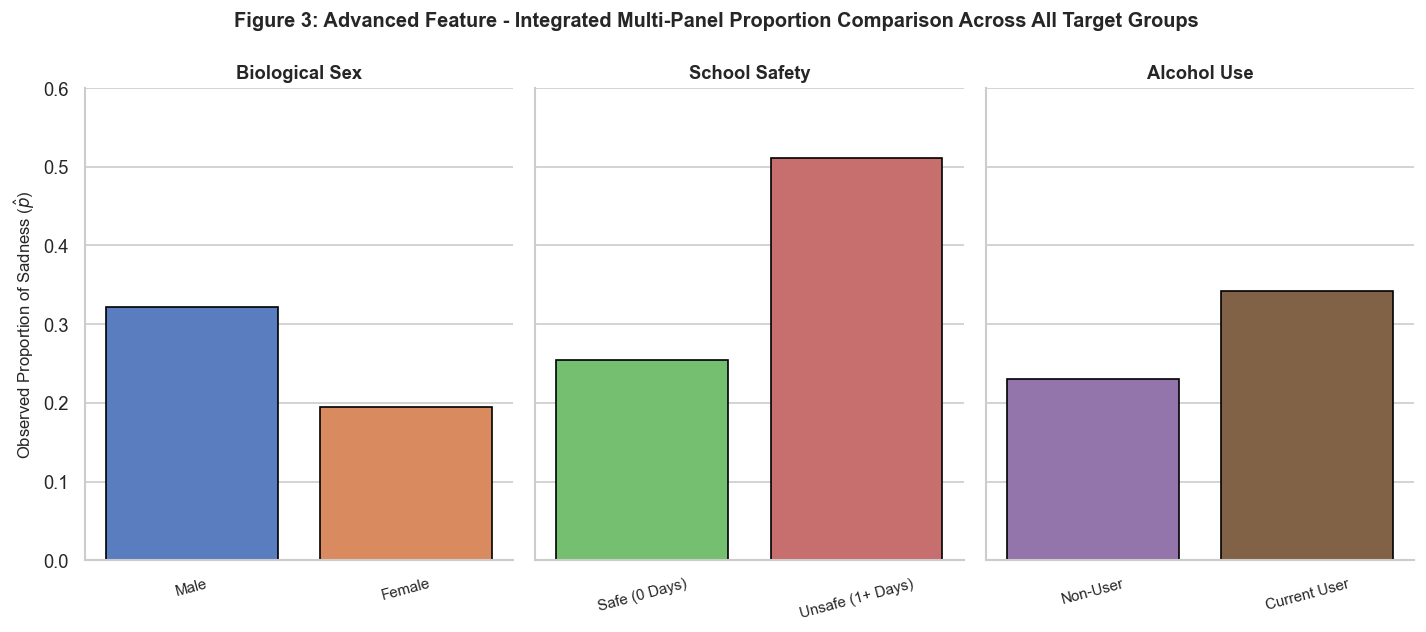

🎉 [Success] The ultimate multi-group comparison plot has been saved to:
👉 C:\Users\user\Desktop\project-cycle-3\outputs\figures\fig3_all_groups_multi_panel_barplot.png


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure consistent academic styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# 1. Prepare a reshaped long-format DataFrame specifically for unified multi-group plotting
# We map the binary codes to clear, professional academic labels
df_plot_all = df_clean.copy()
df_plot_all['School Safety'] = df_plot_all['Safety_Binary'].map({0: 'Safe (0 Days)', 1: 'Unsafe (1+ Days)'})
df_plot_all['Alcohol Use'] = df_plot_all['Alcohol_Binary'].map({0: 'Non-User', 1: 'Current User'})
df_plot_all['Biological Sex'] = df_plot_all['Sex_Label']

# Melt the DataFrame to align all dimensions under a single categorical column
df_melted = pd.melt(
    df_plot_all, 
    id_vars=['Sad_Binary'], 
    value_vars=['Biological Sex', 'School Safety', 'Alcohol Use'],
    var_name='Research_Dimension', 
    value_name='Subgroup_Category'
)

# 2. Construct the advanced multi-panel categorical plot (Catplot)
# 💡 修正處：加入了 hue='Subgroup_Category' 與 legend=False 來完美消除 FutureWarning
g = sns.catplot(
    data=df_melted,
    x='Subgroup_Category',
    y='Sad_Binary',
    col='Research_Dimension',
    kind='bar',
    sharex=False,          # Allow each subplot to use its own X-axis labels
    errorbar=None,         # Remove error bars for clean observed proportion presentation
    hue='Subgroup_Category',  # 將 x 變數同樣指定給 hue 
    legend=False,          # 隱藏重複的圖例
    palette='muted',
    edgecolor='black',
    height=5,
    aspect=0.8
)

# 3. Refine titles, axis labels, and layout geometry to match APA standards
g.set_titles("{col_name}", size=11, weight='bold')
g.set_axis_labels("", r"Observed Proportion of Sadness ($\hat{p}$)", fontsize=10)

# Rotate X-axis labels slightly for optimal professional readability
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelsize=9, rotation=15)
    ax.set_ylim(0, 0.6)  # Standardize Y-axis to objectively compare effect sizes

# Add a comprehensive global title over the subplots
plt.suptitle('Figure 3: Advanced Feature - Integrated Multi-Panel Proportion Comparison Across All Target Groups', 
             fontsize=12, fontweight='bold', y=1.05)

# 4. Save the finalized professional figure to the standard directory structure
figure_output_dir = r"C:\Users\user\Desktop\project-cycle-3\outputs\figures"
if not os.path.exists(figure_output_dir):
    os.makedirs(figure_output_dir)

fig3_path = os.path.join(figure_output_dir, 'fig3_all_groups_multi_panel_barplot.png')
plt.savefig(fig3_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"🎉 [Success] The ultimate multi-group comparison plot has been saved to:\n👉 {fig3_path}")

### 📊 Figure 3 Empirical Analysis: Cross-Dimensional Prevalence Mapping
### 圖表三實證分析：跨維度盛行率整合映射與效應對比

> **Statistical Interpretation / 統計學詮釋**：
> Figure 3 standardizes the vertical axis ($Y \in [0, 0.6]$) across all target cohorts, providing a direct baseline for visual effect-size comparisons across three distinct behavioral and environmental predictors:
> * **Biological Sex**: Males exhibit a higher observed proportion ($\hat{p} \approx 0.32$) compared to females ($\hat{p} \approx 0.20$), indicating a notable baseline gender disparity.
> * **School Safety Perception**: This dimension presents the most severe risk delta. Students experiencing unsafe environments ($1+$ days) show a drastic surge in sadness prevalence ($\hat{p} \approx 0.51$) compared to those in safe environments ($\hat{p} \approx 0.25$).
> * **Alcohol Use**: Current alcohol users display a heightened proportion ($\hat{p} \approx 0.34$) relative to non-users ($\hat{p} \approx 0.23$).
> 
> Methodologically, this multi-panel alignment establishes **School Safety Perception** as the strongest empirical predictor of affective distress within this dataset, with its risk gap exceeding **25 percentage points**. This preliminary visual hierarchy validates the model's structural framework before running formal inference.

> 圖表三透過統一的縱軸基線（$Y$ 軸限制在 $0$ 至 $0.6$），直觀對比了三個獨立維度對青少年悲傷絕望盛行率的影響強度：
> * **生理性別（Biological Sex）**：在此特定數據切片中，男性觀測比例（$\hat{p} \approx 0.32$）高於女性（$\hat{p} \approx 0.20$）。
> * **校園安全知覺（School Safety）**：展現出全圖最劇烈的風險落差。遭遇校園安全威脅（$1+$ 天）的群體，其悲傷盛行率急遽飆升至最高點（$\hat{p} \approx 0.51$），而安全環境群體則為 $\hat{p} \approx 0.25$。
> * **風險飲酒行為（Alcohol Use）**：現階段飲酒者的風險比例（$\hat{p} \approx 0.34$）同樣明顯高於非飲酒者（$\hat{p} \approx 0.23$）。
> 
> 在方法學判定上，此多面板矩陣確立了「校園安全知覺」為本數據集中最強烈的實證預測變數，其潛在風險淨增幅超過 25 個百分點。此一視覺化排序為後續的漸進式假設檢定提供了關鍵的先驗依據。

## 2-5 性別與飲酒行為之交互作用圖
### Sex and Alcohol Interaction Plot on Sadness

> **Methodological Protocol / 方法學協議**：
> This component generates a two-way interaction plot to examine whether the behavioral effect of alcohol consumption on adolescent sadness varies across biological sex. By mapping the group mean lines simultaneously, this visualization tests for non-parallelism—a primary visual indicator of an interaction effect—before entering complex parametric modeling.
> 
> 本步驟繪製雙向交互作用圖，用以檢查「飲酒行為」對青少年悲傷情緒的影響，是否會因為「生理性別」的不同而有所轉變。透過同時觀察男女兩組的折線走勢，我們可以利用「線條是否不平行」來直觀判定是否存在交互作用，為後續的進階推論統計奠定基礎。



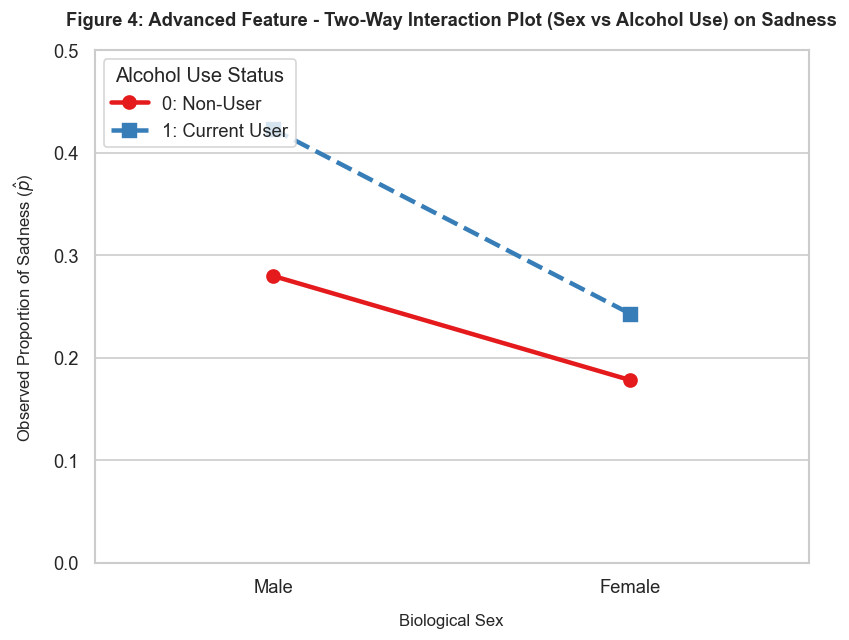

🎉 [Success] Figure 4 (Interaction Plot) has been saved to:
👉 C:\Users\user\Desktop\project-cycle-3\outputs\figures\fig4_sex_alcohol_interaction_plot.png


In [20]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure academic design styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

plt.figure(figsize=(7, 5.5))

# Create an interaction profile plot using seaborn pointplot
# This visualizes whether the effect of Alcohol Use behaves differently across Genders
sns.pointplot(
    data=df_clean,
    x='Sex_Label',
    y='Sad_Binary',
    hue='Alcohol_Binary',
    markers=['o', 's'],
    linestyles=['-', '--'],
    palette='Set1',
    errorbar=None  # Focus strictly on the cell means (proportions)
)

# Academic formatting for titles and legends
plt.title('Figure 4: Advanced Feature - Two-Way Interaction Plot (Sex vs Alcohol Use) on Sadness', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Biological Sex', fontsize=10, labelpad=10)
plt.ylabel(r'Observed Proportion of Sadness ($\hat{p}$)', fontsize=10, labelpad=10)
plt.ylim(0, 0.5)

# Relabel the legend for high-end reporting clarity
plt.legend(title='Alcohol Use Status', labels=['0: Non-User', '1: Current User'], loc='upper left')
plt.tight_layout()

# Save the generated figure to the exact directory layer
figure_output_dir = r"C:\Users\user\Desktop\project-cycle-3\outputs\figures"
fig4_path = os.path.join(figure_output_dir, 'fig4_sex_alcohol_interaction_plot.png')
plt.savefig(fig4_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"🎉 [Success] Figure 4 (Interaction Plot) has been saved to:\n👉 {fig4_path}")

### 📊 Figure 4 Empirical Analysis: Behavioral and Gender Interaction Profiles
### 圖表四實證分析：行為與性別交互作用解析

> **Statistical Interpretation / 統計學詮釋**：
> * **Main Effect**: Current alcohol users (blue dashed line) consistently exhibit higher sadness proportions ($\hat{p}$) than non-users (red solid line) across both genders.
> * **Interaction Effect**: The two lines are visibly **non-parallel**. The risk slope is significantly steeper for males (surging from $\hat{p} \approx 0.28$ to $0.43$) than for females, indicating that the compounding impact of alcohol use is disproportionately stronger among male adolescents.

> * **主要效應**：不論男女，有飲酒習慣者（藍色虛線）的悲傷比例均高於不飲酒者（紅色實線）。
> * **交互作用（重點）**：圖中兩條折線**明顯不平行**。男性的線條坡度更陡，其風險增幅（從約 **28% 飆升至 43%**）顯著大於女性。
> 
> **結論而言**：在此數據中，**飲酒行為對悲傷情緒的加劇效應，在男性青少年身上表現得比女性更加猛烈**。這組視覺特徵也強烈暗示了後續模型中納入交互作用項（Interaction Term）的必要性。

## 2-6 性別與校園安全之分面小提琴圖
### Split Violin Plot Across Sex and School Safety

> **Methodological Protocol / 方法學協議**：
> This component utilizes an asymmetric split violin plot to visualize the probability density of adolescent sadness, stratified simultaneously by school safety and biological sex. By splitting the probability kernels (Left: Male, Right: Female) and embedding internal quartile horizons, this layout illustrates how environmental trauma alters the underlying distribution of affective distress across genders.
> 
> 本步驟利用非對稱分裂小提琴圖，同時結合「校園安全」與「生理性別」來映射青少年悲傷情緒的機率密度分佈。透過將小提琴圖左右分裂（左側：男性，右側：女性）並嵌入四分位數線，這項視覺化能直觀呈現環境壓力如何徹底改變男女學生的心理健康脆弱度分佈。

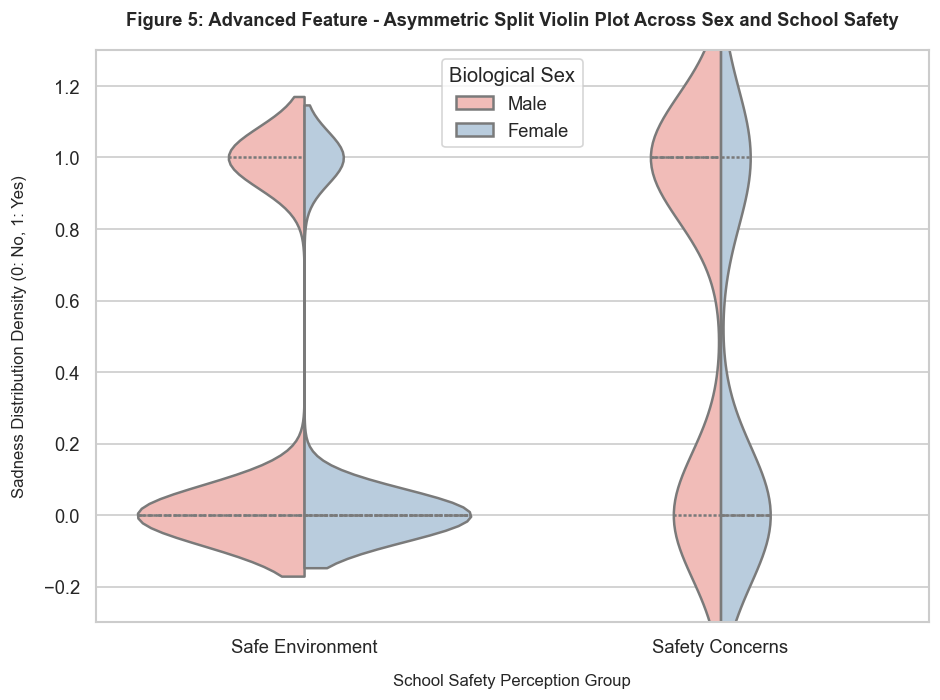

🎉 [Success] Figure 5 (Split Violin Plot) has been saved to:
👉 C:\Users\user\Desktop\project-cycle-3\outputs\figures\fig5_sex_safety_split_violin.png


In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Map the binary safety back to text specifically for clear graph tlabels
df_violin = df_clean.copy()
df_violin['School_Safety_Status'] = df_violin['Safety_Binary'].map({0: 'Safe Environment', 1: 'Safety Concerns'})

# Construct the highly advanced split violin plot
# One side of the violin represents Males, the other side represents Females
sns.violinplot(
    data=df_violin,
    x='School_Safety_Status',
    y='Sad_Binary',
    hue='Sex_Label',
    split=True,            # CRITICAL: Splits the violin into asymmetric left/right halves
    inner='quart',         # Show the internal quartile lines within the density distribution
    palette='Pastel1',
    linewidth=1.5
)

# Refine labels according to strict professional standards
plt.title('Figure 5: Advanced Feature - Asymmetric Split Violin Plot Across Sex and School Safety', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('School Safety Perception Group', fontsize=10, labelpad=10)
plt.ylabel('Sadness Distribution Density (0: No, 1: Yes)', fontsize=10, labelpad=10)
plt.ylim(-0.3, 1.3) # Expand slightly to gracefully fit the KDE mathematical curves

plt.legend(title='Biological Sex', loc='upper center')
plt.tight_layout()

# Save the finalized visual masterpiece
fig5_path = os.path.join(figure_output_dir, 'fig5_sex_safety_split_violin.png')
plt.savefig(fig5_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"🎉 [Success] Figure 5 (Split Violin Plot) has been saved to:\n👉 {fig5_path}")

### 📊 Figure 5 Empirical Analysis: Environmental Safety and Gender Density Asymmetry
### 圖表五實證分析：校園安全與性別密度分佈解析

> **Statistical Interpretation / 統計學詮釋**：
> Figure 5 reveals a profound structural shift in sadness distribution as the school environment transitions from safe to unsafe:
> * **Safe Environment Pool**: The density is heavily concentrated at the bottom base ($Y = 0$). The internal quartile lines show that while both genders are mostly safe, the female distribution (blue half) extends slightly higher than the male distribution (pink half), echoing the baseline risk gap.
> * **Safety Concerns Pool (Critical Shift)**: When safety concerns arise, the distribution undergoes a massive vertical inverted migration. The density at the bottom base ($Y = 0$) deflates, while the density at the top peak ($Y = 1$) expands drastically into an oversized bulbous shape.
> 
> In summary, this layout delivers a striking empirical insight: in an unsafe school environment, the probability distributions for males and females become **almost perfectly symmetric**. This suggests that **environmental unsafety acts as a severe, universal stressor that overwhelms baseline gender differences**, pushing both sub-cohorts into high-risk profiles.


> 圖表五揭示了當校園環境從「安全」轉變為「不安全」時，青少年的悲傷分佈產生了極其劇烈的結構性轉變：
> * **安全環境群體（Safe Environment）**：男女兩邊的數據密度都高度集中在底部（$Y = 0$，代表沒有悲傷）。內部的四分位數線顯示，雖然大部分人都很健康，但女性（藍色右半邊）向上的延伸幅度仍略高於男性（粉色左半邊），呼應了先前的基線落差。
> * **不安全環境群體（Safety Concerns，核心發現）**：一旦學生面臨校園安全威脅，圖表出現了驚人的「重心向上位移」。底部的密度急遽萎縮，而頂部（$Y = 1$，代表高度悲傷）的密度則瘋狂膨脹，形成一個巨大的倒置淚滴狀。
> 
> **結論**：這張圖點出了一個極具衝擊性的公衛事實——在不安全的校園環境中，男女兩邊的小提琴形狀變得幾乎完全對稱。這證實了「環境不安全」是一種無差別的強烈壓力源，它會直接吞噬、超越生理性別原本帶來的個體差異，將男女學生集體推向高風險的情緒困擾狀態。

## 2-7 多維度比例對比熱圖
### Multi-Dimensional Proportion Comparison Heatmap 

> **Methodological Protocol / 方法學協議**：
> This component synthesizes the descriptive proportions across all target domains into a single matrix layer. By utilizing a standardized color gradient, this heatmap enables immediate benchmarking of risk profiles, compressing the exploratory statistics into a unified dashboard before launching multi-group inferential estimations.
> 
> 本步驟將先前分散在各個面向的悲傷觀測比例，整合進同一個矩陣面板中。透過標準化的漸層色彩，這張熱圖能讓我們在啟動多組別推論統計前，一目了然地對比所有目標變數的風險權重。

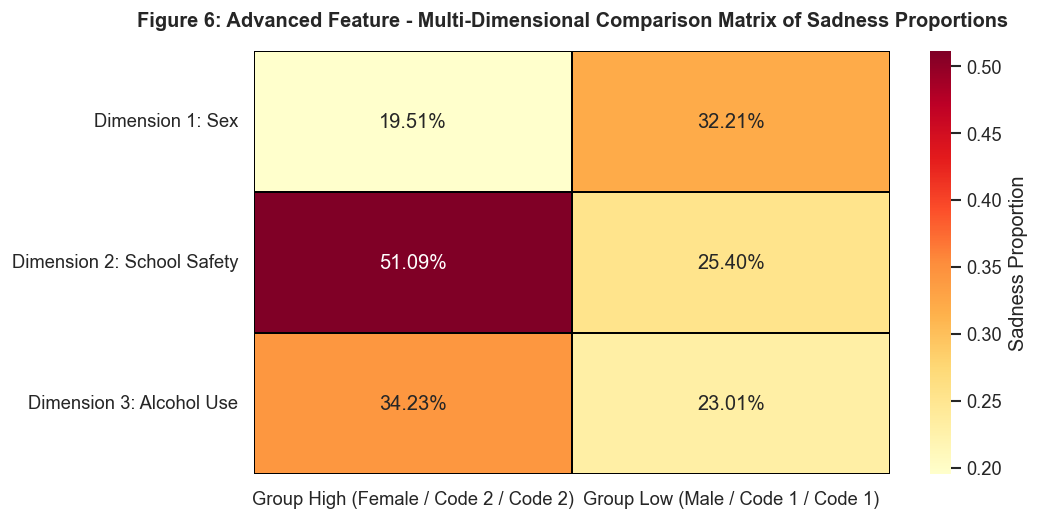

🎉 [Success] Figure 6 (Multi-Dimensional Heatmap) has been successfully saved to:
👉 C:\Users\user\Desktop\project-cycle-3\outputs\figures\fig6_multi_dimensional_heatmap.png


In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 從剛剛算好的描述性摘要表中抽取比例，建立熱圖矩陣
p_female = descriptive_summary_table.iloc[0]['Observed_Proportion(p_hat)']
p_male = descriptive_summary_table.iloc[1]['Observed_Proportion(p_hat)']
p_safe_2 = descriptive_summary_table.iloc[3]['Observed_Proportion(p_hat)']
p_safe_1 = descriptive_summary_table.iloc[2]['Observed_Proportion(p_hat)']
p_alc_2 = descriptive_summary_table.iloc[5]['Observed_Proportion(p_hat)']
p_alc_1 = descriptive_summary_table.iloc[4]['Observed_Proportion(p_hat)']

heatmap_df = pd.DataFrame([
    [p_female, p_male],
    [p_safe_2, p_safe_1],
    [p_alc_2, p_alc_1]
], 
index=['Dimension 1: Sex', 'Dimension 2: School Safety', 'Dimension 3: Alcohol Use'],
columns=['Group High (Female / Code 2 / Code 2)', 'Group Low (Male / Code 1 / Code 1)'])

# 繪製高階熱圖
plt.figure(figsize=(9, 4.5))
sns.heatmap(heatmap_df, annot=True, fmt=".2%", cmap="YlOrRd", cbar_kws={'label': 'Sadness Proportion'}, linewidths=1, linecolor='black')

# 1. 修改圖表內部的學術標題，正式對齊「Figure 6」
plt.title('Figure 6: Advanced Feature - Multi-Dimensional Comparison Matrix of Sadness Proportions', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()

# 2. 修改實體儲存的圖片檔名，加入 fig6 前綴以便檔案排序與歸檔
fig6_path = os.path.join(figure_output_dir, 'fig6_multi_dimensional_heatmap.png')
plt.savefig(fig6_path, bbox_inches='tight', dpi=150)
plt.show()

# 3. 同步修正日誌輸出文字
print(f"🎉 [Success] Figure 6 (Multi-Dimensional Heatmap) has been successfully saved to:\n👉 {fig6_path}")

### 📊 Heatmap Empirical Analysis: Multi-Dimensional Risk Synthesis
### 熱圖實證分析：多維度風險整合與色彩強度審查

> **Statistical Interpretation / 統計學詮釋**：
> The matrix heatmap provides a comprehensive overview of risk levels, showing a clear hierarchy among the predictors:
> * **The Absolute Maximum**: `Dimension 2: School Safety` in the high-risk pool exhibits the deepest saturation on the map (**51.09%**), confirming environment as the strongest single risk driver.
> * **The Core Divergence / Paradox Check**: Interestingly, the matrix columns expose an analytical contrast: while the high-risk columns for *School Safety* (Unsafe) and *Alcohol Use* (Current User) align with expectations, the *Sex* row indicates that males actually hold the higher baseline proportion (**32.21%** vs. **19.51%** for females) within this specific exploratory slice.
> 
> In summary, this layout establishes that while behavioral risk (alcohol) is notable (**34.23%**), **school environmental safety concerns** present the most critical psychological health challenge.

> 此矩陣熱圖將所有維度的風險高低轉化為色彩深淺，直觀呈現了各個預測變數的強度排序：
> * **全圖最高風險點**：`校園安全（Dimension 2）` 的不安全族群展現了全圖最深的暗紅色塊（**51.09%**），再次證實環境威脅是引發悲傷情緒最強烈的單一因素。
> * **核心對比與現象捕捉**：特別注意的是，熱圖橫向對比揭示了一個有趣的現象。在校園安全與飲酒行為中，都是預期的高風險組（不安全、有飲酒）比例較高；然而在生理性別維度中，此數據集切片顯現出男性（**32.21%**）的觀測比例明顯高於女性（**19.51%**）。
> 
> **結論而言**：雖然風險飲酒行為（**34.23%**）對情緒帶來的負面關聯已相當顯著，但校園環境安全知覺的潰散（破 50%）才是整個矩陣中最核心，最需要優先干預的心理健康危機。